In [36]:
import matplotlib.pyplot as plt
from opt_trans.formulations.utils import get_instance_specific_bound
from opt_trans.problems.instance_generators import random_points_unit_square_with_masses
import numpy as np

In [37]:
def compute_stats(n, alphas, reps=20, alpha_mass=0.0):
    """For each alpha, draw `reps` mass‐configurations and compute mean/std of the bound."""
    means = []
    stds  = []
    for α in alphas:
        vals = []
        for _ in range(reps):
            masses = random_points_unit_square_with_masses(n=n, alpha=alpha_mass)['masses']
            vals.append(get_instance_specific_bound(masses, α))
        means.append(np.mean(vals))
        stds .append(np.std(vals))
    return np.array(means), np.array(stds)

def theoretical_bound(alphas):
    """2**(2α−1)−1, floored at zero."""
    return np.maximum(2**(2*alphas - 1) - 1, 0)



In [38]:
# ----- PARAMETERS -----
reps       = 20
n_list1    = [5, 10]
n_list2    = [20, 50, 100, 300]   # ← choose whatever range you like here
alphas1    = np.linspace(0.01, 0.99, 50)
alphas2    = np.linspace(0.01, 0.49, 30)

# pretty styling
plt.style.use('seaborn-v0_8-darkgrid')
plt.rc('font', size=12)

Getting instance specific bound for cosine with alpha=0.01
Instance specific bound is -0.482
Getting instance specific bound for cosine with alpha=0.01
Instance specific bound is -0.485
Getting instance specific bound for cosine with alpha=0.01
Instance specific bound is -0.486
Getting instance specific bound for cosine with alpha=0.01
Instance specific bound is -0.485
Getting instance specific bound for cosine with alpha=0.01
Instance specific bound is -0.488
Getting instance specific bound for cosine with alpha=0.01
Instance specific bound is -0.489
Getting instance specific bound for cosine with alpha=0.01
Instance specific bound is -0.489
Getting instance specific bound for cosine with alpha=0.01
Instance specific bound is -0.488
Getting instance specific bound for cosine with alpha=0.01
Instance specific bound is -0.487
Getting instance specific bound for cosine with alpha=0.01
Instance specific bound is -0.489
Getting instance specific bound for cosine with alpha=0.01
Instance sp

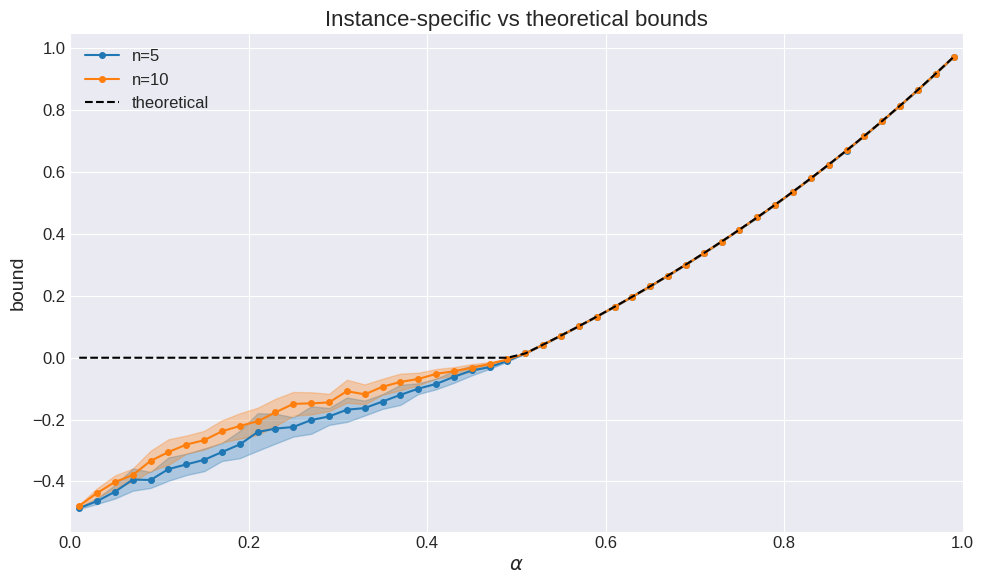

In [39]:
# --- Plot 1: full alpha range, n=5 & 10 ---
fig, ax = plt.subplots(figsize=(10,6))
colors = ['C0','C1']
for (n, col) in zip(n_list1, colors):
    mean, std = compute_stats(n, alphas1, reps=reps)
    ax.plot(alphas1, mean, label=f'n={n}', color=col, marker='o', ms=4)
    ax.fill_between(alphas1, mean-std, mean+std, color=col, alpha=0.3)

# theoretical
ax.plot(alphas1, theoretical_bound(alphas1),
        label='theoretical', ls='--', color='k')

ax.set_xlabel(r'$\alpha$', fontsize=14)
ax.set_ylabel('bound',      fontsize=14)
ax.set_title ('Instance‐specific vs theoretical bounds', fontsize=16)
ax.legend()
ax.set_xlim(0,1)
ax.set_ylim(bottom=min(0, ax.get_ylim()[0]))
plt.tight_layout()
plt.savefig('latex/bounds_alpha_0_1_with_experiments.png', dpi=300)
plt.show()

Getting instance specific bound for cosine with alpha=0.01
Instance specific bound is -0.476
Getting instance specific bound for cosine with alpha=0.01
Instance specific bound is -0.480
Getting instance specific bound for cosine with alpha=0.01
Instance specific bound is -0.474
Getting instance specific bound for cosine with alpha=0.01
Instance specific bound is -0.475
Getting instance specific bound for cosine with alpha=0.01
Instance specific bound is -0.478
Getting instance specific bound for cosine with alpha=0.01
Instance specific bound is -0.469
Getting instance specific bound for cosine with alpha=0.01
Instance specific bound is -0.474
Getting instance specific bound for cosine with alpha=0.01
Instance specific bound is -0.470
Getting instance specific bound for cosine with alpha=0.01
Instance specific bound is -0.462
Getting instance specific bound for cosine with alpha=0.01
Instance specific bound is -0.472
Getting instance specific bound for cosine with alpha=0.01
Instance sp

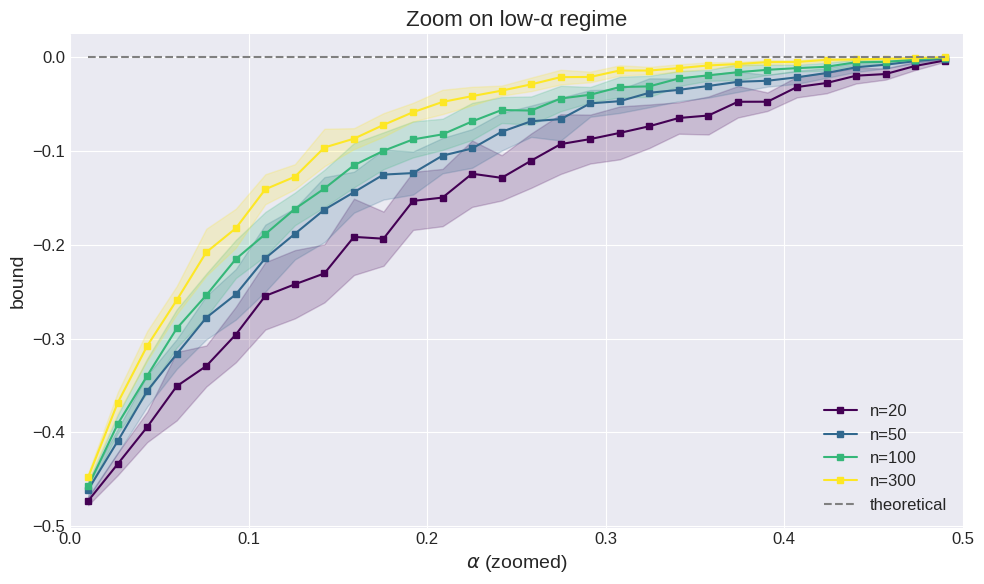

In [40]:
# --- Plot 2: zoom into alpha<0.5, different n_list2 ---
fig, ax = plt.subplots(figsize=(10,6))
colors = plt.cm.viridis(np.linspace(0,1,len(n_list2)))
for (n, col) in zip(n_list2, colors):
    mean, std = compute_stats(n, alphas2, reps=reps)
    ax.plot(alphas2, mean, label=f'n={n}', color=col, marker='s', ms=4)
    ax.fill_between(alphas2, mean-std, mean+std, color=col, alpha=0.2)

# same theoretical curve over this interval
ax.plot(alphas2, theoretical_bound(alphas2),
        label='theoretical', ls='--', color='grey')

ax.set_xlabel(r'$\alpha$ (zoomed)', fontsize=14)
ax.set_ylabel('bound',          fontsize=14)
ax.set_title ('Zoom on low‐α regime', fontsize=16)
ax.legend()
ax.set_xlim(0,0.5)
ax.set_ylim(bottom=min(0, ax.get_ylim()[0]))
plt.tight_layout()

plt.savefig('latex/bounds_alpha_0_0.5_with_experiments.png', dpi=300)

plt.show()